# The 11-20 Game

**Inspired by:** Arad, A., & Rubinstein, A. (2012). The 11–20 money request game: A level-k reasoning study. _American Economic Review_, 102(7), 3561-3573.

> You and another player are playing a game in which each player requests an amount of money. The amount must be an integer) between 11 and 20 shekels. Each player will receive the amount he requests. A player will receive an additional amount of 20 shekels if he asks for exactly one shekel less than the other player. What amount of money would you request?

The goal of this little example is to show how to implement a Cognitive Hierarchy model where a player reasoning at level $k$ assumes that the opponent reasons at level $k^\prime$ drawn from a Poisson distribution truncated to $k^\prime < k$.

According to Arad & Rubinstein, this model should predict that the optimal strategy is to pick 17 not only at level 3 but also at level 4. This is in contrast to a standard level-$k$ model, where the opponent is modeled as reasoning at level $k-1$, and where the optimal strategy would be to pick 16 at level 4. We reproduce this result.

In [1]:
from memo import memo
import jax.numpy as np
from matplotlib import pyplot as plt
from jax.scipy.stats.poisson import pmf as poisson_pmf

from typing import no_type_check

In [2]:
N = np.arange(11, 20 + 1)  # set of n's player can choose from
K = np.arange(6)  # set of k's we will compute predictions for
lambda_ = 2.36  # Poisson param, estimated by Arad & Rubinstein

In [3]:
def is_salient(n):
    return n == 20

@no_type_check
@memo
def game[k: K, n: N](limit=100):
    player: knows(k)
    player: wants(payoff=n + (20 if n == opponent.n - 1 else 0))
    player: thinks[
        opponent: knows(k),
        opponent: given(k_ in K, wpp=poisson_pmf(k_, {lambda_}) * (k_ < k)),
        opponent: chooses(
            n in N,
            wpp=1 if limit < 0 else
            is_salient(n) if k_ <= 0 else
            game[k_, n](limit - 1)
        )
    ]
    player: chooses(n in N, to_maximize=EU[payoff] if k > 0 else is_salient(n))
    return Pr[player.n == n]

%time predictions = game()

CPU times: user 273 ms, sys: 16.1 ms, total: 289 ms
Wall time: 156 ms


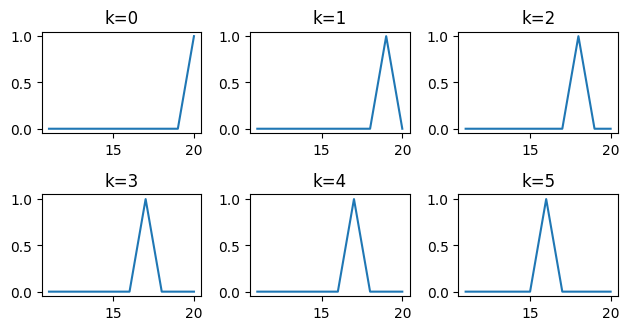

In [4]:
for k in K:
    plt.subplot(3, 3, int(k + 1))
    plt.plot(N, predictions[k])
    plt.title(f'k={k}')
plt.tight_layout()